In [6]:
import os
import sys
import h5py
import yaml
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from matplotlib import pyplot as plt
import colorsys
import matplotlib
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties

labelfont = FontProperties()
labelfont.set_family('serif')
labelfont.set_name('Times New Roman')
labelfont.set_size(14)

axislabelfont = FontProperties()
axislabelfont.set_family('serif')
axislabelfont.set_name('Times New Roman')
axislabelfont.set_size(22)

tickfont = FontProperties()
tickfont.set_family('serif')
tickfont.set_name('Times New Roman')
tickfont.set_size(16)

axisfontsize = 16
labelfontsize = 16

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams['text.usetex'] = True

In [3]:
from snnae_v2 import SNNAE, AE
from data_utils import get_cms_data, get_top_data
from dataset import cdataset

# CMS data

In [4]:
data = get_cms_data( num_events_per_class=20000, add_one_hot=False, drop_angles=True, pt_norm_method="max_per_category" )

sm data shape before any preprocessing: (20000, 19, 3)
sm data shape after dropping angles: (20000, 19, 1)
sm data shape after flattening: (20000, 19)


In [5]:
sm_dataset = cdataset( data["sm"], labels=np.zeros( data["sm"].shape[0] ) )
h0_dataset = cdataset( np.concatenate( [data["sm"],data["h0"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["h0"].shape[0])] ) )
hc_dataset = cdataset( np.concatenate( [data["sm"],data["hc"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["hc"].shape[0])] ) )
a4l_dataset = cdataset( np.concatenate( [data["sm"],data["a4l"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["a4l"].shape[0])] ) )
lq_dataset = cdataset( np.concatenate( [data["sm"],data["lq"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["lq"].shape[0])] ) )

batch_size = 1000

train_loader = DataLoader( sm_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_h0 = DataLoader( h0_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_hc = DataLoader( hc_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_a4l = DataLoader( a4l_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_lq = DataLoader( lq_dataset, batch_size=batch_size, shuffle=True, drop_last=True )

In [25]:
def full_snn_run( run_name, input_dim, beta, thresh, num_steps, layers, latent_dim, lr, num_epochs, num_nets ):
    os.mkdir(run_name)
    save_args = {    "input_dim":input_dim,
                "beta":beta,
                "thresh":thresh,
                "num_steps":num_steps,
                "layers":layers,
                "latent_dim":latent_dim,
                "lr":lr,
                "num_epochs":num_epochs,
                "num_nets":num_nets
           }
    with open( run_name + '/args.yaml', 'w' ) as f:
        yaml.dump(save_args, f, default_flow_style=False)
    run_args = {    "input_dim":input_dim,
                "beta":beta,
                "thresh":thresh,
                "num_steps":num_steps,
                "layers":layers,
                "latent_dim":latent_dim,
                "lr":lr,
           }
    labels = {"A4l":'$A_{4l}$',"h0":'$h_0$',"hc":'$h_+$',"LQ":'$\phi$'}
    colors = {"A4l":'b',"h0":'r',"hc":'g',"LQ":'m'}
    sig_loaders = {"A4l":test_loader_a4l,"h0":test_loader_h0,"hc":test_loader_hc,"LQ":test_loader_lq}
    all_sparsity = []
    all_tpr = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    all_inv_fpr = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    all_auc = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    auc_mean = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    auc_std = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    all_inv_fpr_at_0_3 = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    inv_fpr_at_0_3_mean = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    inv_fpr_at_0_3_std = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    for i in range(num_nets):
        print( f'-- NET {i} --') 
        net = SNNAE( **run_args )
        net.train_model( train_loader, num_epochs=num_epochs )
        all_sparsity.append( net.eval_sparsity(train_loader) )
        for sig in ["A4l","h0","hc","LQ"]:
            tpr, inv_fpr, roc_auc, inv_fpr_at_0_3 = net.eval_model(sig_loaders[sig])
            all_tpr[sig].append(tpr)
            all_inv_fpr[sig].append(inv_fpr)
            all_auc[sig].append(roc_auc)
            all_inv_fpr_at_0_3[sig].append(inv_fpr_at_0_3)
    sparsity_mean = np.mean(all_sparsity)
    sparsity_std = np.std(all_sparsity)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_box_aspect(1)
    target_tprs = np.linspace(0, 1, 100)
    for sig in ["A4l","h0","hc","LQ"]:
        collected_inv_fprs = []
        auc_mean[sig] = np.mean(all_auc[sig])
        auc_std[sig] = np.std(all_auc[sig])
        inv_fpr_at_0_3_mean[sig] = np.mean(all_inv_fpr_at_0_3[sig])
        inv_fpr_at_0_3_std[sig] = np.std(all_inv_fpr_at_0_3[sig])
        for target in target_tprs:
            inv_fprs_at_target = []
            for tpr, inv_fpr in zip(all_tpr[sig], all_inv_fpr[sig]):
                if len(tpr) == 0:
                    continue
                idx = np.argmin(np.abs(tpr - target))  # Index of closest TPR
                inv_fprs_at_target.append(inv_fpr[idx])
            collected_inv_fprs.append(inv_fprs_at_target)
        collected_inv_fprs = np.array(collected_inv_fprs, dtype=float)
        mean_inv_fpr = np.mean(collected_inv_fprs, axis=1)
        std_inv_fpr = np.std(collected_inv_fprs, axis=1)
        ax.plot(target_tprs, mean_inv_fpr, color=colors[sig], lw=2, label=f'{labels[sig]}')
        ax.fill_between(target_tprs, mean_inv_fpr - std_inv_fpr, mean_inv_fpr + std_inv_fpr, color=colors[sig], alpha=0.3)
    ax.plot([1-i/10000 for i in range(10000)], [1/(1-i/10000) for i in range(10000)], color='gray', linestyle='--')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\epsilon_s$', fontsize=16)
    ax.set_ylabel(r'$\epsilon_b^{-1}$', fontsize=16)
    ax.set_ylim(1,1000)
    ax.legend(loc="upper right")
    ax.grid(True)
    for sig in ["A4l","h0","hc","LQ"]:
        print('---')
        print(sig)
        print(f"AUC: {auc_mean[sig]} +/- {auc_std[sig]}")
        print(f"inv_fpr_at_0_3: {inv_fpr_at_0_3_mean[sig]} +/- {inv_fpr_at_0_3_std[sig]}")
        print('---')
    fig.savefig( run_name+'/roc.png', dpi=400 )
    with open( run_name+'/stats.txt', 'w' ) as f:
        for sig in ["A4l","h0","hc","LQ"]:
            f.write( sig + f' - AUC: {auc_mean[sig]} +- {auc_std[sig]}, inv_fpr_0.3: {inv_fpr_at_0_3_mean[sig]} +- {inv_fpr_at_0_3_std[sig]}' + '\n' )
        f.write( f'sparsity: {sparsity_mean} +- {sparsity_std}' + '\n' )
    with open( run_name+'/losses.txt', 'w' ) as f:
        f.write( str([ i for i in net.loss_hist ]) )
    fig.show()

-- NET 0 --
ModuleList(
  (0): Linear(in_features=19, out_features=12, bias=True)
  (1): Leaky()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): Leaky()
  (4): Linear(in_features=24, out_features=5, bias=True)
  (5): Leaky()
)
ModuleList(
  (0): Linear(in_features=5, out_features=12, bias=True)
  (1): Leaky()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): Leaky()
  (4): Linear(in_features=24, out_features=19, bias=True)
  (5): Leaky()
)
epoch 0 - loss: 0.037957124225795266
epoch 1 - loss: 0.028675603307783605
epoch 2 - loss: 0.021484947856515647
epoch 3 - loss: 0.01607220759615302
epoch 4 - loss: 0.012050427636131645


/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


-- NET 1 --
ModuleList(
  (0): Linear(in_features=19, out_features=24, bias=True)
  (1): Leaky()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): Leaky()
  (4): Linear(in_features=12, out_features=5, bias=True)
  (5): Leaky()
)
ModuleList(
  (0): Linear(in_features=5, out_features=24, bias=True)
  (1): Leaky()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): Leaky()
  (4): Linear(in_features=12, out_features=19, bias=True)
  (5): Leaky()
)
epoch 0 - loss: 0.06028175707906484
epoch 1 - loss: 0.049287622421979906
epoch 2 - loss: 0.04030061047524214
epoch 3 - loss: 0.03299806918948889
epoch 4 - loss: 0.027064758352935314


/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


-- NET 2 --
ModuleList(
  (0): Linear(in_features=19, out_features=12, bias=True)
  (1): Leaky()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): Leaky()
  (4): Linear(in_features=24, out_features=5, bias=True)
  (5): Leaky()
)
ModuleList(
  (0): Linear(in_features=5, out_features=12, bias=True)
  (1): Leaky()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): Leaky()
  (4): Linear(in_features=24, out_features=19, bias=True)
  (5): Leaky()
)
epoch 0 - loss: 0.03480629725381732
epoch 1 - loss: 0.026299635879695415
epoch 2 - loss: 0.019707152154296637
epoch 3 - loss: 0.014756269101053477
epoch 4 - loss: 0.011095030140131712


...

-- NET 3 --
ModuleList(
  (0): Linear(in_features=19, out_features=24, bias=True)
  (1): Leaky()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): Leaky()
  (4): Linear(in_features=12, out_features=5, bias=True)
  (5): Leaky()
)
ModuleList(
  (0): Linear(in_features=5, out_features=24, bias=True)
  (1): Leaky()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): Leaky()
  (4): Linear(in_features=12, out_features=19, bias=True)
  (5): Leaky()
)
epoch 0 - loss: 0.07378580272197724
epoch 1 - loss: 0.06105475481599569
epoch 2 - loss: 0.0503116799518466
epoch 3 - loss: 0.04130582343786955
epoch 4 - loss: 0.03378483522683382


/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


-- NET 4 --
ModuleList(
  (0): Linear(in_features=19, out_features=12, bias=True)
  (1): Leaky()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): Leaky()
  (4): Linear(in_features=24, out_features=5, bias=True)
  (5): Leaky()
)
ModuleList(
  (0): Linear(in_features=5, out_features=12, bias=True)
  (1): Leaky()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): Leaky()
  (4): Linear(in_features=24, out_features=19, bias=True)
  (5): Leaky()
)
epoch 0 - loss: 0.028702644724398853
epoch 1 - loss: 0.021277428790926933
epoch 2 - loss: 0.015735643962398172
epoch 3 - loss: 0.01172698033042252
epoch 4 - loss: 0.008851288352161646


/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae_v2.py:232: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/venvs/ml/lib/python3.10/site-packages/numpy/_core/_methods.py:194: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipykernel_3645/1944980561.py:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


---
A4l
AUC: 0.7348166475 +/- 0.04776508267044293
inv_fpr_at_0_3: 25.376761317092807 +/- 3.2211952707745475
---
---
h0
AUC: 0.6520499344999999 +/- 0.025150500973168885
inv_fpr_at_0_3: 11.940219880674723 +/- 2.3427247243073257
---
---
hc
AUC: 0.847454819 +/- 0.04290936204013575
inv_fpr_at_0_3: 38.26924207634305 +/- 17.90184008435544
---
---
LQ
AUC: 0.7152871345000001 +/- 0.06352265913141351
inv_fpr_at_0_3: 12.976785532055032 +/- 2.884421920097095
---


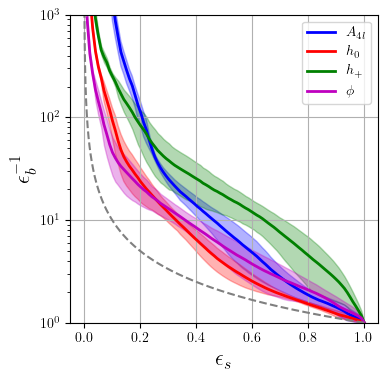

In [27]:
full_snn_run( 'test', data["sm"].shape[-1], 0.5, 1.0, 2, [24,12], 5, 0.001, 5, 5 )